## Exploring Weather Dataset

In [2]:
#Imports
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings 
warnings.filterwarnings('ignore')

In [3]:
weather_df = pd.read_csv('data/weather_data.csv')
weather_df.head(5)

,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,"{Temperature},{Humdity}",Weather Type
0,0.002638888888888889KM/S,82.0,partly cloudy,1010.82,2,Wentar,3.5,inland,"{""Temperature"": {""value"": 14.0, ""unit"": ""C""}, ...",Rainy
1,8.5,71.0,partly CLOUDY,1011.43,7,Spring,10.0,inland,"{""Temperature"": {""value"": 39.0, ""unit"": ""C""}, ...",Cloudy
2,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,"{""Temperature"": {""value"": 30.0, ""unit"": ""C""}, ...",Sunny
3,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,"{""Temperature"": {""value"": 38.0, ""unit"": ""C""}, ...",Sunny
4,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,"{""Temperature"": {""value"": 27.0, ""unit"": ""C""}, ...",Rainy


In [4]:
weather_df.info()
weather_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Wind Speed               13200 non-null  object 
 1   Precipitation (%)        13200 non-null  object 
 2   Cloud Cover              13200 non-null  object 
 3   Atmospheric Pressure     13200 non-null  float64
 4   UV Index                 13200 non-null  int64  
 5   Season                   13200 non-null  object 
 6   Visibility (km)          13200 non-null  float64
 7   Location                 13200 non-null  object 
 8   {Temperature},{Humdity}  13200 non-null  object 
 9   Weather Type             13200 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.0+ MB


,Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000
mean,1005.827896,4.005758,5.462917
std,37.199589,3.856600,3.371499
min,800.120000,0.000000,0.000000
25%,994.800000,1.000000,3.000000
50%,1007.650000,3.000000,5.000000
75%,1016.772500,7.000000,7.500000
max,1199.210000,14.000000,20.000000


In [5]:
#Missing values
for col in weather_df.columns:
    missing = weather_df[col].isnull().sum()
    print(f'{col}: {missing} missing values')

Wind Speed: 0 missing values
Precipitation (%): 0 missing values
Cloud Cover: 0 missing values
Atmospheric Pressure: 0 missing values
UV Index: 0 missing values
Season: 0 missing values
Visibility (km): 0 missing values
Location: 0 missing values
{Temperature},{Humdity}: 0 missing values
Weather Type: 0 missing values


In [6]:
#Outliers
for col in weather_df.columns:
    if weather_df[col].dtype in ['int64', 'float64']:
        q1 = weather_df[col].quantile(0.25)
        q3 = weather_df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = weather_df[(weather_df[col] < lower_bound) | (weather_df[col] > upper_bound)]
        print(f'{col}: {len(outliers)} outliers')

Atmospheric Pressure: 927 outliers
UV Index: 0 outliers
Visibility (km): 383 outliers


In [7]:
weather_df['Wind Speed'].unique()

array(['0.002638888888888889KM/S', '8.5', '7.0', '1.5', '17.0', '3.5',
       '0.0022222222222222222KM/S', '6.0', '2000.0M/H', '10.5', '15.0',
       '6.5', '0.5', '0.0001388888888888889KM/S', '12000.0M/H', '12.5',
       '7.5', '13.5', '1.0', '7500.0M/H', '4.0', '16.0', '16.5', '2.5',
       '0.006388888888888889KM/S', '0.0008333333333333334KM/S', '10.0',
       '0.007083333333333333KM/S', '19.0', '11500.0M/H', '2.0',
       '0.002777777777777778KM/S', '0.0', '9.0', '9.5', '18500.0M/H',
       '0.0030555555555555557KM/S', '20.0', '14000.0M/H', '5.5', '13.0',
       '18.5', '14.0', '0.012916666666666667KM/S', '8.0', '3.0',
       '3500.0M/H', '5.0', '18000.0M/H', '12.0',
       '0.007916666666666667KM/S', '14.5', '11.0', '0.005KM/S', '0.0M/H',
       '4.5', '15.5', '0.0002777777777777778KM/S',
       '0.0077777777777777776KM/S', '18.0', '0.0005555555555555556KM/S',
       '4500.0M/H', '0.0025KM/S', '19.5', '6500.0M/H', '10500.0M/H',
       '0.0015277777777777779KM/S', '11000.0M/H', '11

In [8]:
#Convert 'Wind Speed' to numeric, coercing errors to NaN
weather_df['Wind Speed'] = pd.to_numeric(weather_df['Wind Speed'], errors='coerce')

In [9]:
weather_df.dropna(subset= ['Wind Speed'], inplace=True)

In [10]:
#Look at random rows 
weather_df.sample(10)

,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,"{Temperature},{Humdity}",Weather Type
6517,10.0,67.0,overcast,988.80,1,It rains every day....,4.5,mountain,"{""Temperature"": {""value"": 3.0, ""unit"": ""C""}, ""...",Snowy
9529,11.5,64.0,overcast,999.81,0,Wentar,4.0,mountain,"{""Temperature"": {""value"": -10.0, ""unit"": ""C""},...",Snowy
1261,4.0,12.0,cloudy,975.85,5,Autumn,12.5,mountain,"{""Temperature"": {""value"": 17.0, ""unit"": ""C""}, ...",Sunny
9818,8.0,92.0,Party cloudy,1000.29,1,Spring,1.5,mountain,"{""Temperature"": {""value"": 27.0, ""unit"": ""C""}, ...",Rainy
8698,13.5,65.0,overcast,992.21,0,Winter,4.5,inland,"{""Temperature"": {""value"": -5.0, ""unit"": ""C""}, ...",Snowy
914,8.5,73.0,overcast,998.45,1,Winter,2.0,inland,"{""Temperature"": {""value"": -17.0, ""unit"": ""C""},...",Snowy
4029,5.0,107.0percent,OVRCST,1007.51,6,you can call it Autumn or Fall,3.5,inland,"{""Temperature"": {""value"": 9.0, ""unit"": ""C""}, ""...",Cloudy
10550,30.0,87.0,partly Cloudy,1018.69,12,Winter,5.0,inland,"{""Temperature"": {""value"": 28.0, ""unit"": ""C""}, ...",Rainy
1489,7.5,39.0,overcast,1018.48,1,It rains every day....,9.0,coastal,"{""Temperature"": {""value"": 15.0, ""unit"": ""C""}, ...",Cloudy
8456,1.5,7.0,clr,1024.84,8,Autumn,7.5,coastal,"{""Temperature"": {""value"": 41.0, ""unit"": ""C""}, ...",Sunny


In [11]:
weather_df['Precipitation (%)'].unique()

array(['71.0', '16.0', '82.0', '66.0', '26.0', '96.0', '107.0', '86.0',
       '25.0', '67.0', '8.0', '46.0', '13.0', '27.0', '75.0', '98.0',
       '18.0', '29.0', '101.0', '85.0', '12.0', '3.0', '54.0', '97.0',
       '63.0', '56.0', '6.0', '109.0', '58.0', '9.0', '0.0', '39.0',
       '14.0', '37.0', '88.0', '55.0', '90.0', '4.0', '68.0', '32.0',
       '87.0', '17.0', '89.0', '57.0', '84.0', '83.0', '47.0', '99.0',
       '92.0', '19.0', '60.0percent', '11.0', '15.0', '5.0', '43.0',
       '2.0', '59.0', '79.0', '94.0', '42.0', '53.0', '72.0', '73.0',
       '81.0', '91.0', '45.0', '76.0', '22.0', '40.0', '78.0', '50.0',
       '10.0', '35.0', '95.0', '103.0', '62.0', '7.0', '74.0', '48.0',
       '69.0', '57.0percent', '60.0', '64.0', '31.0', '106.0', '24.0',
       '52.0', '51.0', '1.0', '80.0', '93.0', '23.0', '70.0', '41.0',
       '20.0', '104.0', '82.0%', '21.0', '77.0', '30.0', '65.0', '61.0',
       '50.0%', '33.0', '38.0', '72.0%', '34.0', '57.0%', '36.0', '28.0',
       '

In [12]:
weather_df['Precipitation (%)'] = pd.to_numeric(weather_df['Precipitation (%)'], errors='coerce')
weather_df.dropna(subset= ['Precipitation (%)'], inplace=True)
weather_df.sample(10)

,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,"{Temperature},{Humdity}",Weather Type
10582,8.0,4.0,clear,1028.04,11,Winter,7.0,mountain,"{""Temperature"": {""value"": 29.0, ""unit"": ""C""}, ...",Sunny
9260,16.0,86.0,overcast,1007.09,1,Summer,2.0,mountain,"{""Temperature"": {""value"": 29.0, ""unit"": ""C""}, ...",Rainy
1540,5.0,64.0,overcast,994.57,0,Winter,5.0,mountain,"{""Temperature"": {""value"": -5.0, ""unit"": ""C""}, ...",Snowy
4960,3.0,74.0,partly CLOUDY,1011.53,13,Autumn,6.0,mountain,"{""Temperature"": {""value"": 17.0, ""unit"": ""C""}, ...",Cloudy
12975,13.5,49.0,overcast,1014.47,1,It rains every day....,7.5,mountain,"{""Temperature"": {""value"": 23.0, ""unit"": ""C""}, ...",Cloudy
6448,12.0,94.0,clear,1022.52,11,Winter,1.5,coastal,"{""Temperature"": {""value"": 73.0, ""unit"": ""C""}, ...",Sunny
9611,16.0,81.0,clear,1025.75,5,Spring,3.0,coastal,"{""Temperature"": {""value"": 65.0, ""unit"": ""C""}, ...",Sunny
3434,8.5,16.0,clr,1013.57,5,Spring,5.5,mountain,"{""Temperature"": {""value"": 38.0, ""unit"": ""C""}, ...",Sunny
12374,18.0,90.0,partly Cloudy,994.71,0,Winter,3.5,inland,"{""Temperature"": {""value"": -6.0, ""unit"": ""C""}, ...",Snowy
10045,14.5,74.0,overcast,1005.70,7,winter,2.0,coastal,"{""Temperature"": {""value"": 58.0, ""unit"": ""C""}, ...",Rainy


In [13]:
weather_df['Season'].unique()

array(['Spring', 'Winter', 'Summer', 'Autumn', 'It is so hot outside',
       'It rains every day....', 'summer', 'sumer', 'I hate summer',
       'Fall', 'autum', 'Wentar', 'Wintar',
       'you can call it Autumn or Fall ', 'winter',
       'trees lose their leaves in this time'], dtype=object)

In [14]:
#Replace season values with either Summer, Autumn, Winter or Spring
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
weather_df = weather_df[weather_df['Season'].isin(seasons)]
weather_df['Season'].unique()

array(['Spring', 'Winter', 'Summer', 'Autumn'], dtype=object)

In [15]:
weather_df['Season'].unique()

array(['Spring', 'Winter', 'Summer', 'Autumn'], dtype=object)

In [16]:
weather_df['Cloud Cover'].unique()

array(['partly CLOUDY', 'clear', 'overcast', 'partly cloudy', 'Clr',
       'Party cloudy', 'partly cloddy', 'clr', 'partly Cloudy', 'Clear',
       'cleer', 'cloudy'], dtype=object)

In [17]:
#Map cloud cover values to either Clear, Partly Cloudy, Cloudy or Overcast

cloud_cover_mapping = {
    'Clear': 'Clear',
    'Partly Cloudy': 'Partly Cloudy',
    'Cloudy': 'Cloudy',
    'Overcast': 'Overcast',
    'partly CLOUDY': 'Partly Cloudy',
    'clear': 'Clear',
    'overcast': 'Overcast',
    'partly cloudy': 'Partly Cloudy',
    'Clr': 'Clear',
    'Party cloudy': 'Partly Cloudy',
    'partly cloddy': 'Partly Cloudy',
    'clr': 'Clear',
    'partly Cloudy': 'Partly Cloudy',
    'cleer': 'Clear',
    'cloudy': 'Cloudy'}

weather_df['Cloud Cover'] = weather_df['Cloud Cover'].map(cloud_cover_mapping)
weather_df['Cloud Cover'].unique()



array(['Partly Cloudy', 'Clear', 'Overcast', 'Cloudy'], dtype=object)

In [18]:
#Replace season values with either Summer, Autumn, Winter or Spring
seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
weather_df = weather_df[weather_df['Season'].isin(seasons)]


In [19]:
weather_df.sample(10)

,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,"{Temperature},{Humdity}",Weather Type
9290,6.0,1.0,Partly Cloudy,1028.24,11,Winter,7.5,coastal,"{""Temperature"": {""value"": 20.0, ""unit"": ""C""}, ...",Sunny
10563,4.0,72.0,Overcast,998.67,0,Winter,2.5,inland,"{""Temperature"": {""value"": -10.0, ""unit"": ""C""},...",Snowy
11535,3.0,11.0,Clear,1022.40,10,Spring,6.0,inland,"{""Temperature"": {""value"": 43.0, ""unit"": ""C""}, ...",Sunny
3507,4.5,18.0,Partly Cloudy,1013.83,11,Autumn,8.5,inland,"{""Temperature"": {""value"": 28.0, ""unit"": ""C""}, ...",Sunny
12955,13.0,54.0,Overcast,986.20,0,Winter,1.0,inland,"{""Temperature"": {""value"": 4.0, ""unit"": ""C""}, ""...",Snowy
3468,17.5,82.0,Clear,1028.49,4,Winter,11.5,mountain,"{""Temperature"": {""value"": 27.0, ""unit"": ""C""}, ...",Sunny
11864,13.5,22.0,Partly Cloudy,1008.57,3,Spring,8.0,inland,"{""Temperature"": {""value"": 19.0, ""unit"": ""C""}, ...",Cloudy
6389,0.5,60.0,Overcast,993.96,1,Winter,4.5,mountain,"{""Temperature"": {""value"": -5.0, ""unit"": ""C""}, ...",Snowy
1206,14.0,106.0,Clear,1023.29,12,Winter,8.0,coastal,"{""Temperature"": {""value"": 76.0, ""unit"": ""C""}, ...",Sunny
3360,7.0,76.0,Overcast,985.52,0,Winter,5.0,mountain,"{""Temperature"": {""value"": -7.0, ""unit"": ""C""}, ...",Snowy


In [20]:
#Handling Temperature and Humidity Column splitting it out to two columns


# Part Two: Exploring US Pumpkin Dataset 

In [21]:
from datetime import datetime

In [22]:
pumpkins_df = pd.read_csv('data/US-pumpkins.csv')
pumpkins_df.sample(5)

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
818,COLUMBIA,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,175.0,175.0,175.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
1679,ST. LOUIS,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,9/28/16,125.0,125.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,ABOUT STEADY.
921,COLUMBIA,NaN,24 inch bins,CINDERELLA,NaN,NaN,9/9/17,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
449,BOSTON,NaN,36 inch bins,PIE TYPE,NaN,NaN,10/15/16,220.0,220.0,220.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
1020,COLUMBIA,NaN,1/2 bushel cartons,MINIATURE,FLAT TYPE,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [23]:
pumpkins_df.info()
pumpkins_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        1757 non-null   object 
 1   Type             45 non-null     object 
 2   Package          1757 non-null   object 
 3   Variety          1752 non-null   object 
 4   Sub Variety      296 non-null    object 
 5   Grade            0 non-null      float64
 6   Date             1757 non-null   object 
 7   Low Price        1757 non-null   float64
 8   High Price       1757 non-null   float64
 9   Mostly Low       1654 non-null   float64
 10  Mostly High      1654 non-null   float64
 11  Origin           1754 non-null   object 
 12  Origin District  131 non-null    object 
 13  Item Size        1478 non-null   object 
 14  Color            1141 non-null   object 
 15  Environment      0 non-null      float64
 16  Unit of Sale     162 non-null    object 
 17  Quality       

,Grade,Low Price,High Price,Mostly Low,Mostly High,Environment,Quality,Condition,Appearance,Storage,Crop,Trans Mode,Unnamed: 24
count,0.0,1757.000000,1757.000000,1654.000000,1654.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,124.571338,132.970939,128.170550,132.491802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,83.876591,89.524958,86.512161,88.442967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.240000,0.240000,0.240000,0.240000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,24.000000,24.500000,24.625000,26.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,140.000000,150.000000,147.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,180.000000,200.000000,185.000000,200.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,480.000000,480.000000,480.000000,480.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
#Null Values 
pumpkins_df.isnull().sum()

City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64

In [25]:
#Making a new df with columns that dont have excessive null values
relevant_column = ['Date', 'Low Price', 'High Price', 'Package', 'Variety', 'City Name', 'Month', 'Origin']
pumpkins_df = pumpkins_df.drop(columns= [col for col in pumpkins_df.columns if col not in relevant_column], axis=1)
pumpkins_df.sample(5)

,City Name,Package,Variety,Date,Low Price,High Price,Origin
419,BOSTON,24 inch bins,PIE TYPE,10/29/16,175.0,200.0,MICHIGAN
1716,ST. LOUIS,24 inch bins,MIXED HEIRLOOM VARIETIES,9/29/16,135.0,135.0,MISSOURI
510,BOSTON,24 inch bins,BIG MACK TYPE,10/29/16,260.0,285.0,MASSACHUSETTS
904,COLUMBIA,24 inch bins,HOWDEN WHITE TYPE,9/16/17,200.0,200.0,VIRGINIA
703,CHICAGO,1 1/9 bushel cartons,PIE TYPE,9/9/17,20.0,20.0,ILLINOIS


In [26]:
#Setting Low Price and High Price to numbers and having 2 decimal places since they are prices
pumpkins_df['Low Price'] = pd.to_numeric(pumpkins_df['Low Price'], errors='coerce').round(2)
pumpkins_df['High Price'] = pd.to_numeric(pumpkins_df['High Price'], errors='coerce').round(2)
pumpkins_df.sample(5)

,City Name,Package,Variety,Date,Low Price,High Price,Origin
669,CHICAGO,1 1/9 bushel cartons,PIE TYPE,9/24/16,17.0,18.0,OHIO
1607,PHILADELPHIA,36 inch bins,HOWDEN TYPE,10/15/16,100.0,125.0,PENNSYLVANIA
959,COLUMBIA,24 inch bins,PIE TYPE,10/29/16,250.0,250.0,NORTH CAROLINA
982,COLUMBIA,bushel cartons,PIE TYPE,10/29/16,19.0,19.0,MICHIGAN
1465,SAN FRANCISCO,36 inch bins,HOWDEN TYPE,9/30/17,120.0,135.0,CALIFORNIA


In [27]:
pumpkins_df['Package'].unique()

array(['24 inch bins', '36 inch bins', '50 lb sacks',
       '1 1/9 bushel cartons', '1/2 bushel cartons',
       '1 1/9 bushel crates', 'bushel cartons', 'bins', '35 lb cartons',
       'each', '20 lb cartons', '50 lb cartons', '40 lb cartons',
       'bushel baskets', '22 lb cartons'], dtype=object)

In [28]:
#If the package column contains 'bushel cartons' then we want to keep it and if not we want to drop it 
#Case = True means that it will be case sensitive 
#regex = True means that it will use regular expressions to search for the string
pumpkins_df = pumpkins_df[pumpkins_df['Package'].str.contains('bushel cartons', case=True, regex=True)]

In [29]:
#Setting month column to be the month of the date column
month = pd.DatetimeIndex(pumpkins_df['Date']).month

In [30]:
#Setting Date column to datetime format
day_of_year = pd.to_datetime(pumpkins_df['Date']).apply(lambda dt: (dt-datetime(dt.year,1 , 1)).days)

In [31]:
#Creating a new column called 'Average Price' which is the average of the low price and high price columns
pumpkins_df['Average Price'] = (pumpkins_df['Low Price'] + pumpkins_df['High Price']) / 2
pumpkins_df.sample(5)

,City Name,Package,Variety,Date,Low Price,High Price,Origin,Average Price
691,CHICAGO,1 1/9 bushel cartons,PIE TYPE,11/19/16,17.00,17.00,ILLINOIS,17.000
1733,ST. LOUIS,1/2 bushel cartons,MINIATURE,9/29/16,13.75,15.00,ILLINOIS,14.375
1729,ST. LOUIS,1/2 bushel cartons,MINIATURE,9/28/16,15.00,15.75,ILLINOIS,15.375
538,BOSTON,1/2 bushel cartons,MINIATURE,10/8/16,15.00,18.00,MASSACHUSETTS,16.500
768,CHICAGO,1/2 bushel cartons,MINIATURE,9/30/17,17.00,19.00,MICHIGAN,18.000


In [32]:
new_pumpkins_df = pd.DataFrame({
    'Date':day_of_year,
    'Month': month,
    'Origin': pumpkins_df['Origin'],
    'City': pumpkins_df['City Name'],
    'Variety': pumpkins_df['Variety'],
    'Package': pumpkins_df['Package'],
    'Low Price': pumpkins_df['Low Price'],
    'High Price': pumpkins_df['High Price'],
    'Average Price': pumpkins_df['Average Price']
})

In [33]:
new_pumpkins_df.sample(15)

,Date,Month,Origin,City,Variety,Package,Low Price,High Price,Average Price
1067,295,10,PENNSYLVANIA,COLUMBIA,MINIATURE,bushel cartons,30.00,30.0,30.000
984,265,9,MICHIGAN,COLUMBIA,PIE TYPE,bushel cartons,20.00,20.0,20.000
669,267,9,OHIO,CHICAGO,PIE TYPE,1 1/9 bushel cartons,17.00,18.0,17.500
130,281,10,OHIO,BALTIMORE,MINIATURE,1/2 bushel cartons,16.00,17.0,16.500
981,295,10,MICHIGAN,COLUMBIA,PIE TYPE,bushel cartons,19.00,19.0,19.000
1739,273,9,ILLINOIS,ST. LOUIS,MINIATURE,1/2 bushel cartons,13.75,15.0,14.375
715,309,11,OHIO,CHICAGO,PIE TYPE,1 1/9 bushel cartons,22.50,22.5,22.500
713,295,10,OHIO,CHICAGO,PIE TYPE,1 1/9 bushel cartons,22.50,22.5,22.500
1549,309,11,CALIFORNIA,SAN FRANCISCO,MINIATURE,1/2 bushel cartons,20.00,20.0,20.000
560,309,11,MASSACHUSETTS,BOSTON,MINIATURE,1/2 bushel cartons,15.00,18.0,16.500


# Part Three: Linear Regression(s) 

0.010089025924084616


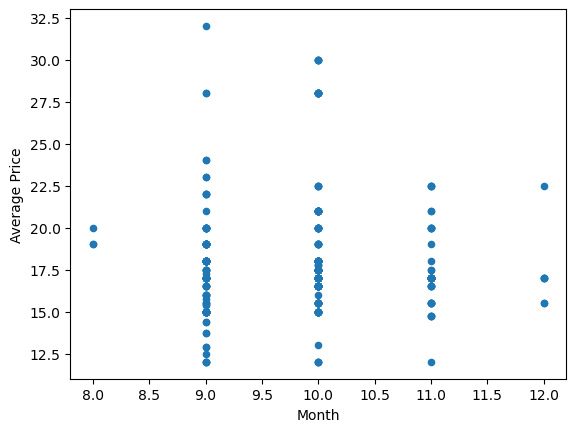

In [37]:
new_pumpkins_df.plot.scatter('Month','Average Price')
print(new_pumpkins_df['Month'].corr(new_pumpkins_df['Average Price']))

<Axes: xlabel='Date', ylabel='Average Price'>

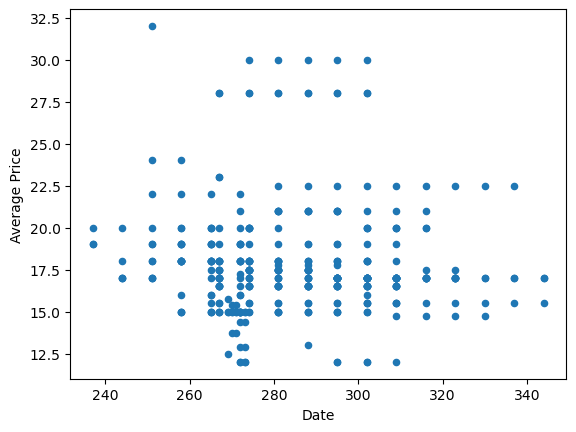

In [36]:
new_pumpkins_df.plot.scatter('Date','Average Price')